In [2]:
import mlflow
import pandas as pd
import numpy as np
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing


In [3]:
housing=fetch_california_housing()
print(housing)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [4]:
X,y=fetch_california_housing(return_X_y=True)

In [5]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [6]:
X[0]

array([   8.3252    ,   41.        ,    6.98412698,    1.02380952,
        322.        ,    2.55555556,   37.88      , -122.23      ])

In [7]:
y[0]

np.float64(4.526)

In [8]:
housing.target_names

['MedHouseVal']

In [9]:
df=pd.DataFrame(X,columns=housing.feature_names)
df['MedHouseVal']=y

In [10]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [11]:
import seaborn as sns

<Axes: xlabel='Latitude', ylabel='Longitude'>

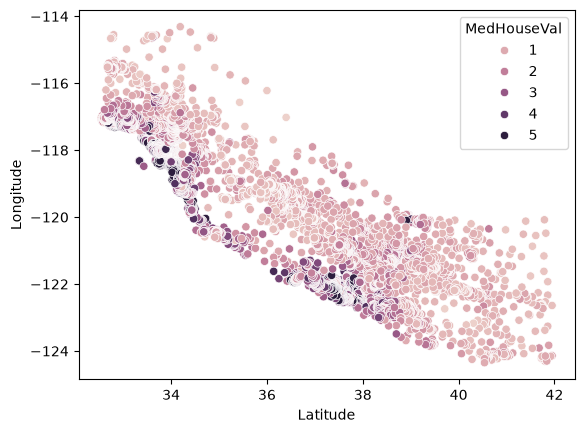

In [12]:
sns.scatterplot(x=df['Latitude'],y=df['Longitude'],hue=df['MedHouseVal'])

In [13]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [29]:
df.corr()['MedHouseVal']

MedInc         0.688075
HouseAge       0.105623
AveRooms       0.151948
AveBedrms     -0.046701
Population    -0.024650
AveOccup      -0.023737
Latitude      -0.144160
Longitude     -0.045967
MedHouseVal    1.000000
Name: MedHouseVal, dtype: float64

In [30]:
type(df.corr())

pandas.core.frame.DataFrame

In [31]:
df['MedHouseVal'].corr(df['AveBedrms'])

np.float64(-0.04670051296948686)

In [34]:
X=df.drop(columns=['MedHouseVal'])
y=df['MedHouseVal']

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [39]:
from urllib.parse import urlparse

In [40]:
signature=infer_signature(X_train,y_train)

In [54]:
param_grid={
    'n_estimators':[100,150],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

In [55]:
def hyperparam_tuning(X_train,y_train,param_grid):
    rf=RandomForestRegressor()
    grid_search=GridSearchCV(estimator=rf,param_grid=param_grid,cv=3,n_jobs=-1,verbose=1,scoring='neg_mean_squared_error')
    grid_search.fit(X_train,y_train)

    return grid_search

In [56]:
## MLFlow experiment
mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment("house price prediction model")
with mlflow.start_run():
    grid_search=hyperparam_tuning(X_train,y_train,param_grid)
    best_model=grid_search.best_estimator_

    y_pred=best_model.predict(X_test)

    mse=mean_squared_error(y_test,y_pred)

    # mlflow logging

    mlflow.log_param("best_n_estimators",grid_search.best_params_['n_estimators'])
    mlflow.log_param("best_max_depth",grid_search.best_params_['max_depth'])
    mlflow.log_param("best_min_samples_split",grid_search.best_params_['min_samples_split'])

    mlflow.log_metric("mse",mse)


    tracking_url_type_store=urlparse(mlflow.get_tracking_uri()).scheme

    if tracking_url_type_store != 'file':
        mlflow.sklearn.log_model(best_model,"model",registered_model_name='best random forest model')

    else:
        mlflow.sklearn.log_model(best_model,"model",signature=signature)

    print(f'best hyperparameter = {grid_search.best_params_}')
    print(f'mse= {mse}')



Fitting 3 folds for each of 12 candidates, totalling 36 fits


2026/07/14 21:11:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/14 21:11:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'best random forest model'.
2026/07/14 21:11:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: best random forest model, version 1
Created version '1' of model 'best random forest model'.


best hyperparameter = {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
mse= 0.2521085279300119
🏃 View run mysterious-grub-579 at: http://127.0.0.1:5000/#/experiments/1/runs/992e28f62fb14550a80dab89c2190bfb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [48]:
X_train.shape

(16512, 8)

In [49]:
y_train.shape

(16512,)